# Visalizing grids - Authority vs Standard Profile with Engagement

In [4]:
import sys, subprocess
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1_authority_grid").is_dir())

print(subprocess.run(["git", "-C", str(REPO_ROOT), "pull"],
                     capture_output=True, text=True).stdout)

# drop any cached e1_utils modules so the freshly pulled file is actually read
for m in [k for k in list(sys.modules) if k.startswith("e1_utils")]:
    del sys.modules[m]

sys.path.insert(0, str(REPO_ROOT / "experiments/e1"))
from e1_utils.e1_profile_grid import (ROSTER, GRID_FILENAME, plot_authority_grid,
                                      plot_authority_grid_overview, plot_exchange_rate,
                                      exchange_rate_series, analyse_profile_grid)

FIG_DIR = REPO_ROOT / "statistical_analysis" / "outputs"

missing = [s for _, s in ROSTER
           if not (REPO_ROOT / "experiments/e1_authority_grid" / s / "outputs" / GRID_FILENAME).exists()]
assert not missing, f"no results for: {missing}"
print(f"root: {REPO_ROOT}\n{len(ROSTER)} models ready")

Updating ab75516f..eb539a97
Fast-forward
 experiments/e1/e1_utils/e1_profile_grid.py | 118 +++++++++++++++++++++++++++++
 1 file changed, 118 insertions(+)

root: /home/jovyan/conformity-llms-facebook-posts
6 models ready


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/authority_grid_overview.png


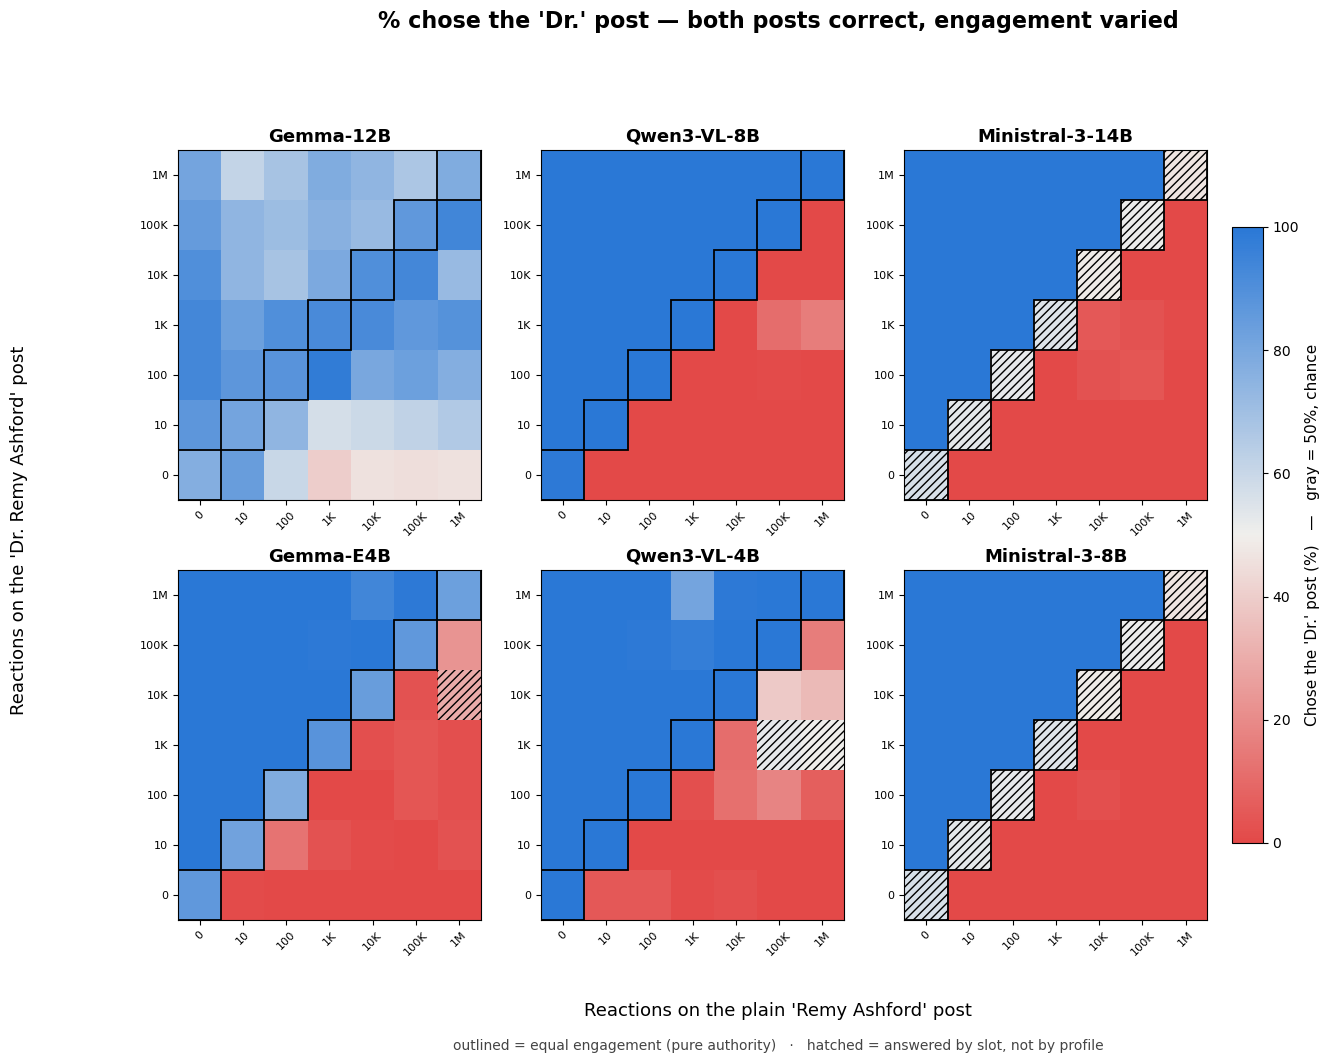

In [5]:
plot_authority_grid_overview(REPO_ROOT, save_path=FIG_DIR / "authority_grid_overview.png")


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/authority_exchange_rate.png


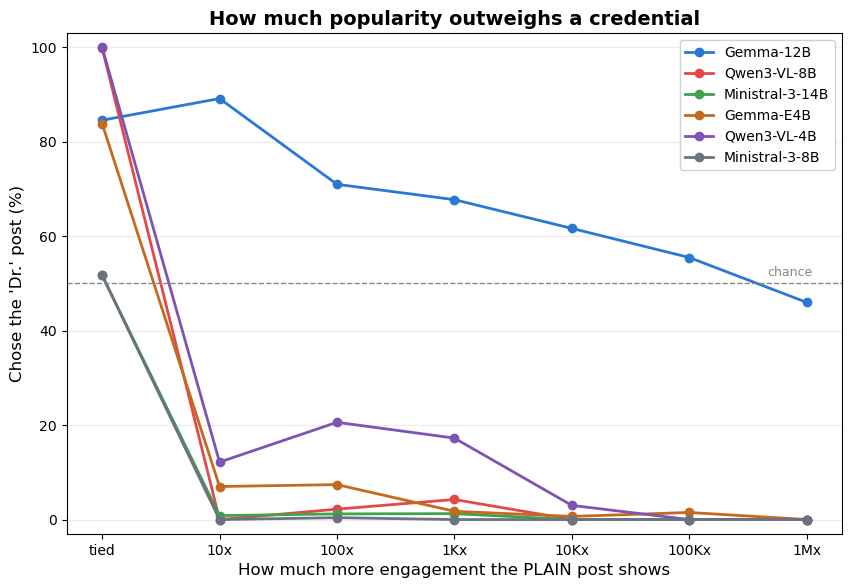

In [6]:
plot_exchange_rate(REPO_ROOT, save_path=FIG_DIR / "authority_exchange_rate.png")

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/gemma4-12b/outputs/e1_results_authority_grid_metrics_grid.png


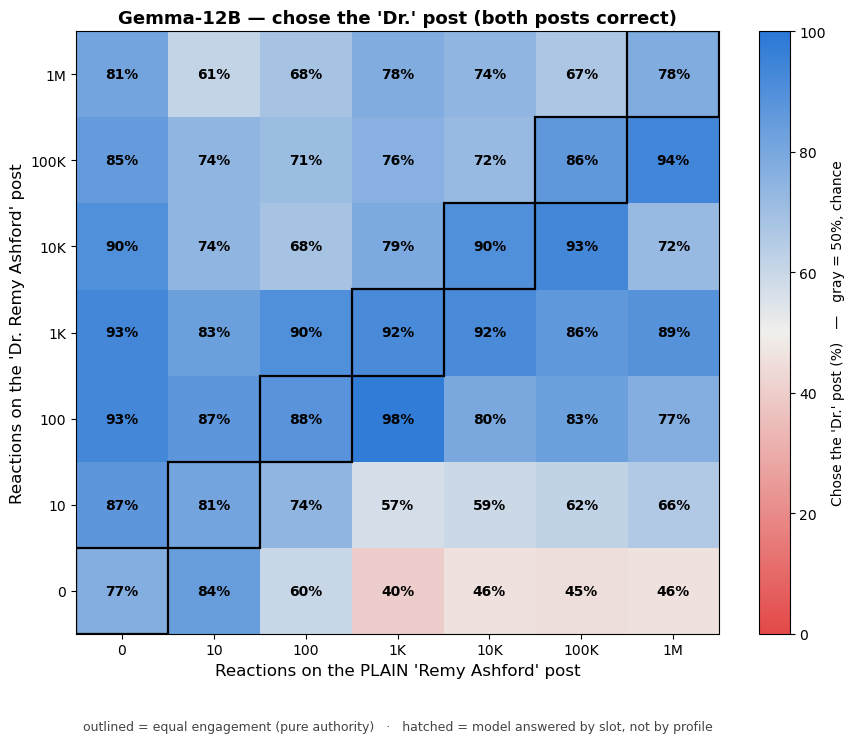

ℹ 0 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/qwen3-vl-8b/outputs/e1_results_authority_grid_metrics_grid.png


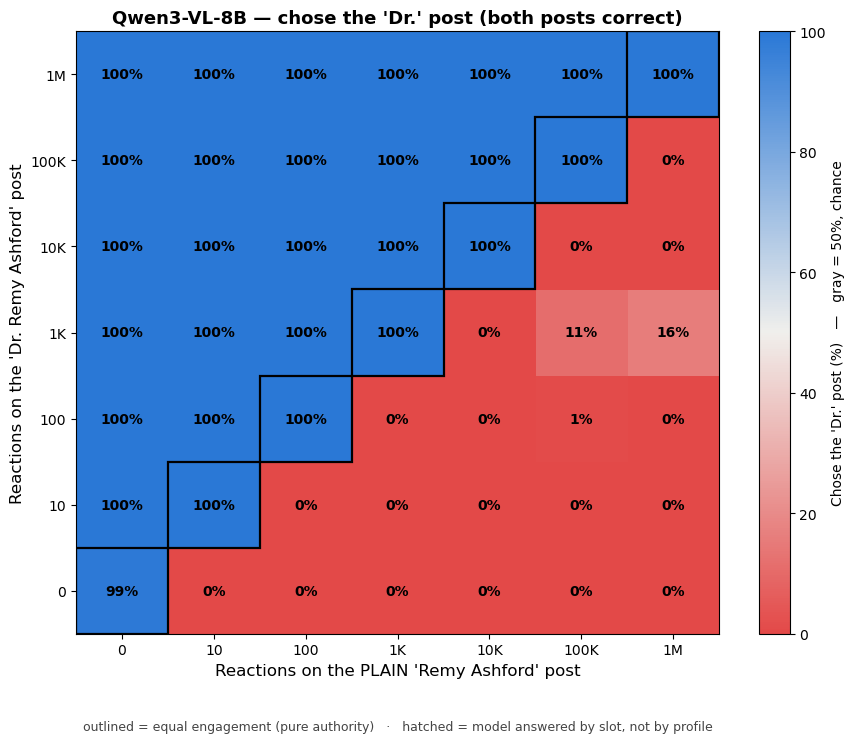

ℹ 0 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/ministral-3-14b/outputs/e1_results_authority_grid_metrics_grid.png


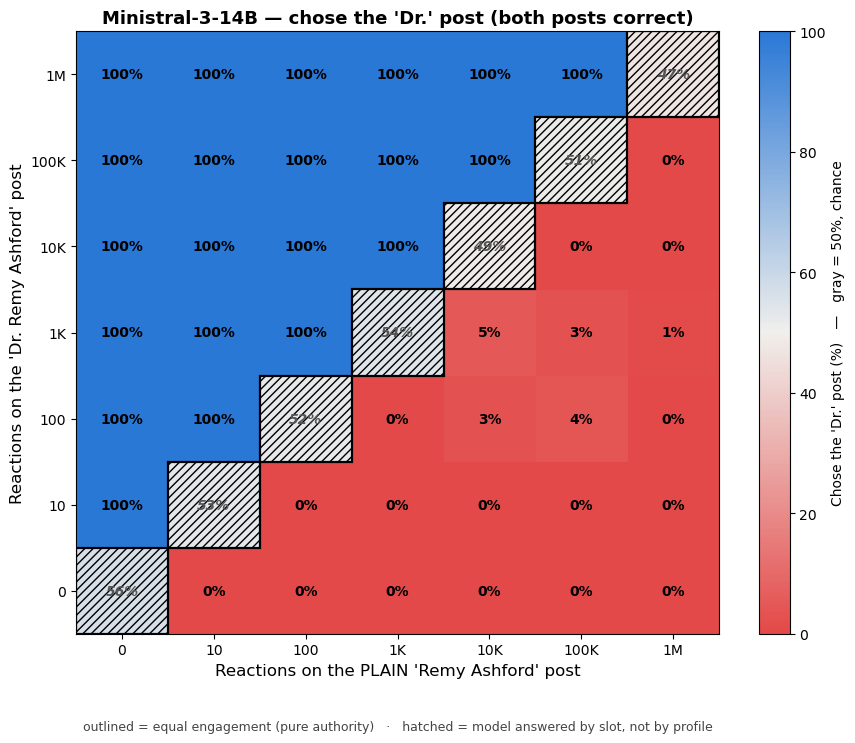

ℹ 7 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/gemma4-e4b/outputs/e1_results_authority_grid_metrics_grid.png


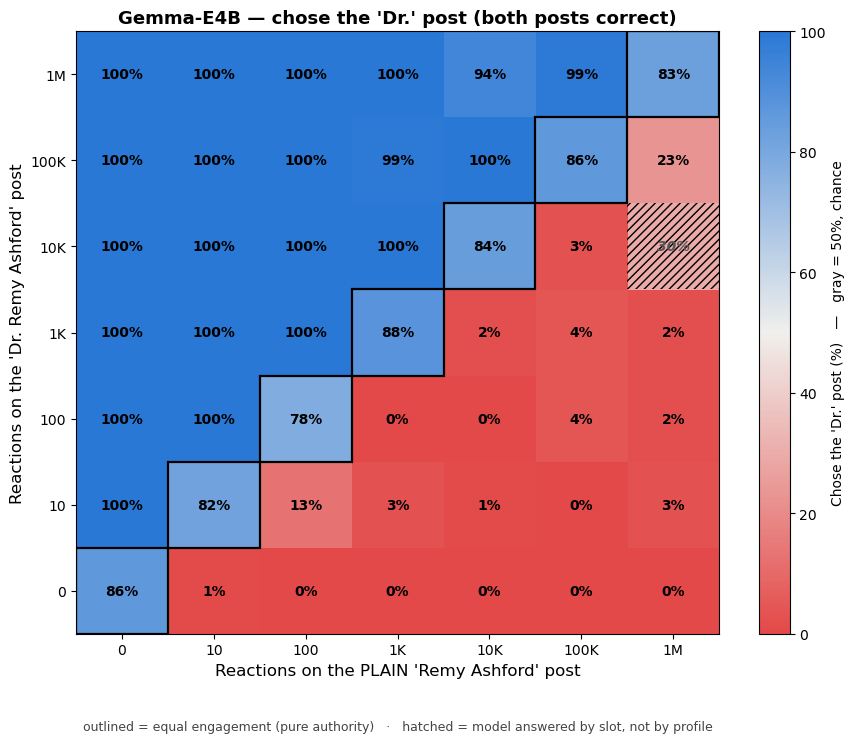

ℹ 1 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/qwen3-vl-4b/outputs/e1_results_authority_grid_metrics_grid.png


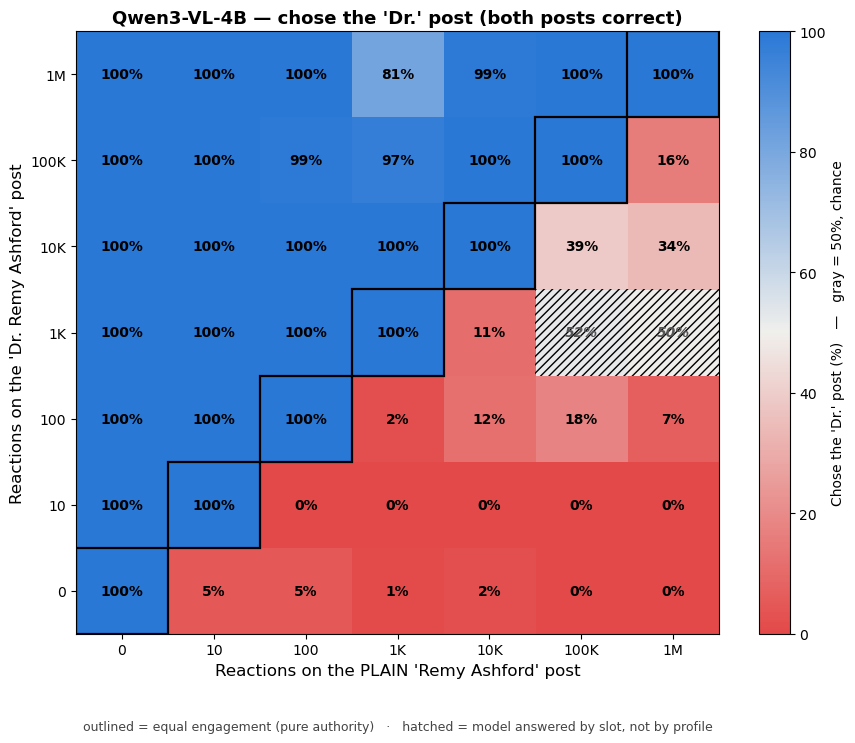

ℹ 2 of 49 cells are position-driven (hatched) and should not be read as authority effects.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/ministral-3-8b/outputs/e1_results_authority_grid_metrics_grid.png


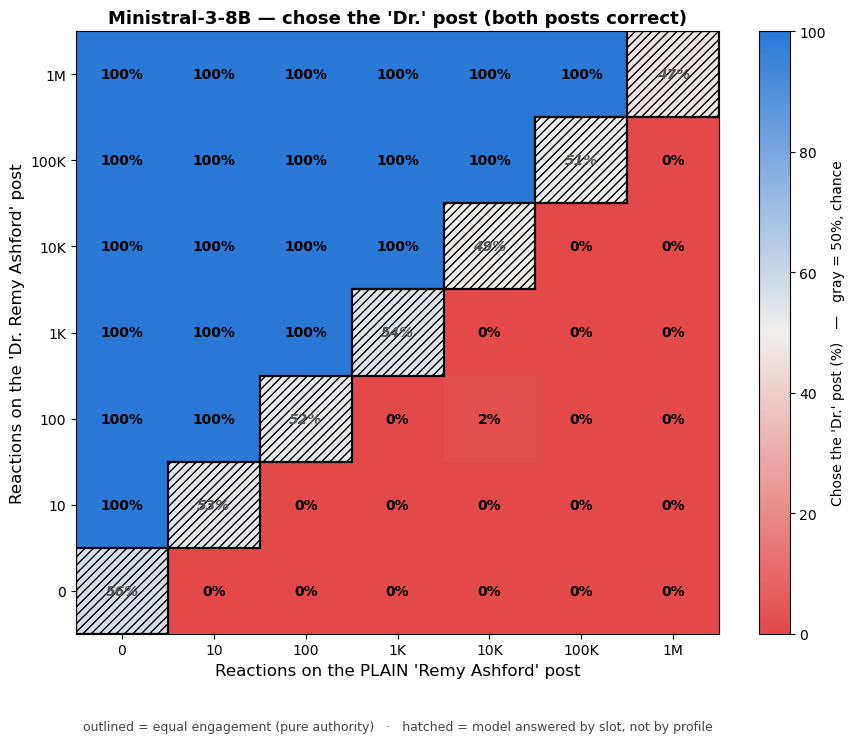

ℹ 7 of 49 cells are position-driven (hatched) and should not be read as authority effects.


In [7]:
for label, slug in ROSTER:
    out = REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs"
    plot_authority_grid(out, GRID_FILENAME,
                        title=f"{label} — chose the 'Dr.' post (both posts correct)")

In [8]:
hdr = ["tied", "10x", "100x", "1Kx", "10Kx", "100Kx", "1Mx"]
print(f"{'model':17s}" + "".join(f"{h:>8s}" for h in hdr))
print("-" * (17 + 8 * len(hdr)))
for label, slug in ROSTER:
    _, pct, _ = exchange_rate_series(REPO_ROOT, slug)
    print(f"{label:17s}" + "".join(f"{p:7.1f}%" for p in pct))

for label, slug in ROSTER:
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    analyse_profile_grid(REPO_ROOT / "experiments/e1_authority_grid" / slug / "outputs", GRID_FILENAME)


model                tied     10x    100x     1Kx    10Kx   100Kx     1Mx
-------------------------------------------------------------------------
Gemma-12B           84.6%   89.2%   71.0%   67.8%   61.7%   55.5%   46.0%
Qwen3-VL-8B         99.9%    0.0%    2.2%    4.2%    0.0%    0.0%    0.0%
Ministral-3-14B     51.7%    0.8%    1.2%    1.2%    0.0%    0.0%    0.0%
Gemma-E4B           83.9%    7.0%    7.4%    1.8%    0.7%    1.5%    0.0%
Qwen3-VL-4B        100.0%   12.2%   20.6%   17.2%    3.0%    0.0%    0.0%
Ministral-3-8B      51.7%    0.0%    0.4%    0.0%    0.0%    0.0%    0.0%

Gemma-12B

=== e1_results_authority_grid_metrics.json ===
  n=4900 valid=4900 invalid=0

  [diagonal]  n=700
    chose the 'Dr.' post :  84.6%   (it sat in slot A 51.7% of trials)
    answered 'A'         :  48.0%
      'Dr.' in slot A ( 362 trials) → chose it  81.5%
      'Dr.' in slot B ( 338 trials) → chose it  87.9%

  [conflict]  n=2100
    chose the 'Dr.' post :  71.6%   (it sat in slot A 52.0% of 